<a href="https://colab.research.google.com/github/Mathieu-Germain/LogicMojo-AI-ML-April26-Mathieu/blob/main/IMDb%2BMovie%2BAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# <font color = blue> IMDb Movie Assignment </font>

You have the data for the 100 top-rated movies from the past decade along with various pieces of information about the movie, its actors, and the voters who have rated these movies online. In this assignment, you will try to find some interesting insights into these movies and their voters, using Python.

##  Task 1: Reading the data

- ### Subtask 1.1: Read the Movies Data.

Read the movies data file provided and store it in a dataframe `movies`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

movies = pd.read_csv('/content/drive/MyDrive/movies.csv')
movies.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
0,La La Land,2016,30000000,151101803,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.9,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA
1,Zootopia,2016,150000000,341268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,7.8,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA
2,Lion,2016,12000000,51738905,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,7.9,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia
3,Arrival,2016,47000000,100546139,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA
4,Manchester by the Sea,2016,9000000,47695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA


- ###  Subtask 1.2: Inspect the Dataframe

Inspect the dataframe for dimensions, null-values, and summary of different numeric columns.

In [83]:
print("the Shape is :", movies.shape)

the Shape is : (100, 62)


In [84]:
movies.isnull() #  Check for null values

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [85]:
movies.isnull().sum() # number of null per column

,0
Title,0
title_year,0
budget,0
Gross,0
actor_1_name,0
...,...
Votes1000,0
VotesUS,0
VotesnUS,0
content_rating,0


In [86]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 62 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   100 non-null    object 
 1   title_year              100 non-null    int64  
 2   budget                  100 non-null    int64  
 3   Gross                   100 non-null    int64  
 4   actor_1_name            100 non-null    object 
 5   actor_2_name            100 non-null    object 
 6   actor_3_name            100 non-null    object 
 7   actor_1_facebook_likes  100 non-null    int64  
 8   actor_2_facebook_likes  99 non-null     float64
 9   actor_3_facebook_likes  98 non-null     float64
 10  IMDb_rating             100 non-null    float64
 11  genre_1                 100 non-null    object 
 12  genre_2                 97 non-null     object 
 13  genre_3                 74 non-null     object 
 14  MetaCritic              95 non-null     flo

In [87]:
movies.describe()

,title_year,budget,Gross,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,IMDb_rating,MetaCritic,Runtime,CVotes10,...,Votes1829F,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS
count,100.000000,1.000000e+02,1.000000e+02,100.000000,99.000000,98.000000,100.000000,95.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2012.820000,7.838400e+07,1.468679e+08,13407.270000,7377.303030,3002.153061,7.883000,78.252632,126.420000,73212.160000,...,7.982000,7.732000,7.723000,7.780000,7.65100,7.624000,7.770000,7.274000,7.958000,7.793000
std,1.919491,7.445295e+07,1.454004e+08,10649.037862,13471.568216,6940.301133,0.247433,9.122066,19.050799,82669.594746,...,0.321417,0.251814,0.260479,0.282128,0.21485,0.213258,0.301344,0.361987,0.232327,0.264099
min,2010.000000,3.000000e+06,2.238380e+05,39.000000,12.000000,0.000000,7.500000,62.000000,91.000000,6420.000000,...,7.300000,7.300000,7.200000,7.200000,7.10000,7.100000,7.000000,6.400000,7.500000,7.300000
25%,2011.000000,1.575000e+07,4.199752e+07,1000.000000,580.000000,319.750000,7.700000,72.000000,114.750000,30587.000000,...,7.700000,7.600000,7.500000,7.600000,7.50000,7.475000,7.500000,7.100000,7.800000,7.600000
50%,2013.000000,4.225000e+07,1.070266e+08,13000.000000,1000.000000,626.500000,7.800000,78.000000,124.000000,54900.500000,...,8.000000,7.700000,7.700000,7.800000,7.65000,7.600000,7.800000,7.300000,7.950000,7.750000
75%,2014.000000,1.500000e+08,2.107548e+08,20000.000000,11000.000000,1000.000000,8.100000,83.500000,136.250000,80639.000000,...,8.200000,7.900000,7.900000,8.000000,7.80000,7.800000,7.925000,7.500000,8.100000,7.925000
max,2016.000000,2.600000e+08,9.366622e+08,35000.000000,96000.000000,46000.000000,8.800000,100.000000,180.000000,584839.000000,...,8.800000,8.700000,8.700000,8.500000,8.10000,8.100000,8.500000,8.200000,8.700000,8.800000


In [88]:
movies.shape

(100, 62)

In [89]:
movies.size # number of cells

6200

In [90]:
movies.ndim # the dimension

2

In [91]:
# Check the column-wise info of the dataframe
movies.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 62 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   100 non-null    object 
 1   title_year              100 non-null    int64  
 2   budget                  100 non-null    int64  
 3   Gross                   100 non-null    int64  
 4   actor_1_name            100 non-null    object 
 5   actor_2_name            100 non-null    object 
 6   actor_3_name            100 non-null    object 
 7   actor_1_facebook_likes  100 non-null    int64  
 8   actor_2_facebook_likes  99 non-null     float64
 9   actor_3_facebook_likes  98 non-null     float64
 10  IMDb_rating             100 non-null    float64
 11  genre_1                 100 non-null    object 
 12  genre_2                 97 non-null     object 
 13  genre_3                 74 non-null     object 
 14  MetaCritic              95 non-null     flo

In [92]:
# Check the summary for the numeric columns
movies.describe()

,title_year,budget,Gross,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,IMDb_rating,MetaCritic,Runtime,CVotes10,...,Votes1829F,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS
count,100.000000,1.000000e+02,1.000000e+02,100.000000,99.000000,98.000000,100.000000,95.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2012.820000,7.838400e+07,1.468679e+08,13407.270000,7377.303030,3002.153061,7.883000,78.252632,126.420000,73212.160000,...,7.982000,7.732000,7.723000,7.780000,7.65100,7.624000,7.770000,7.274000,7.958000,7.793000
std,1.919491,7.445295e+07,1.454004e+08,10649.037862,13471.568216,6940.301133,0.247433,9.122066,19.050799,82669.594746,...,0.321417,0.251814,0.260479,0.282128,0.21485,0.213258,0.301344,0.361987,0.232327,0.264099
min,2010.000000,3.000000e+06,2.238380e+05,39.000000,12.000000,0.000000,7.500000,62.000000,91.000000,6420.000000,...,7.300000,7.300000,7.200000,7.200000,7.10000,7.100000,7.000000,6.400000,7.500000,7.300000
25%,2011.000000,1.575000e+07,4.199752e+07,1000.000000,580.000000,319.750000,7.700000,72.000000,114.750000,30587.000000,...,7.700000,7.600000,7.500000,7.600000,7.50000,7.475000,7.500000,7.100000,7.800000,7.600000
50%,2013.000000,4.225000e+07,1.070266e+08,13000.000000,1000.000000,626.500000,7.800000,78.000000,124.000000,54900.500000,...,8.000000,7.700000,7.700000,7.800000,7.65000,7.600000,7.800000,7.300000,7.950000,7.750000
75%,2014.000000,1.500000e+08,2.107548e+08,20000.000000,11000.000000,1000.000000,8.100000,83.500000,136.250000,80639.000000,...,8.200000,7.900000,7.900000,8.000000,7.80000,7.800000,7.925000,7.500000,8.100000,7.925000
max,2016.000000,2.600000e+08,9.366622e+08,35000.000000,96000.000000,46000.000000,8.800000,100.000000,180.000000,584839.000000,...,8.800000,8.700000,8.700000,8.500000,8.10000,8.100000,8.500000,8.200000,8.700000,8.800000


## Task 2: Data Analysis

Now that we have loaded the dataset and inspected it, we see that most of the data is in place. As of now, no data cleaning is required, so let's start with some data manipulation, analysis, and visualisation to get various insights about the data.

-  ###  Subtask 2.1: Reduce those Digits!

These numbers in the `budget` and `gross` are too big, compromising its readability. Let's convert the unit of the `budget` and `gross` columns from `$` to `million $` first.

In [93]:
movies['budget'] = movies['budget'] / 1000000
movies['Gross'] = movies['Gross'] / 1000000
movies.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
0,La La Land,2016,30.0,151.101803,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.9,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA
1,Zootopia,2016,150.0,341.268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,7.8,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA
2,Lion,2016,12.0,51.738905,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,7.9,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia
3,Arrival,2016,47.0,100.546139,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA
4,Manchester by the Sea,2016,9.0,47.695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA


In [ ]:
# Let display the columns
movies.columns.value_counts()

,count
Title,1
title_year,1
budget,1
Gross,1
actor_1_name,1
...,...
Votes1000,1
VotesUS,1
VotesnUS,1
content_rating,1


-  ###  Subtask 2.2: Let's Talk Profit!

    1. Create a new column called `profit` which contains the difference of the two columns: `gross` and `budget`.
    2. Sort the dataframe using the `profit` column as reference.
    3. Extract the top ten profiting movies in descending order and store them in a new dataframe - `top10`.
    4. Plot a scatter or a joint plot between the columns `budget` and `profit` and write a few words on what you observed.
    5. Extract the movies with a negative profit and store them in a new dataframe - `neg_profit`

In [126]:
# Create the new column named 'profit' by subtracting the 'budget' column from the 'gross' column
movies['profit'] = movies['Gross'] - movies['budget']
movies.head()


,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff,sum_trio_like
94,Boyhood,2014,4.0,25.359200,Ellar Coltrane,Lorelei Linklater,Libby Villari,230,193.0,127.0,...,7.7,7.2,8.0,7.9,R,USA,21.359200,8.95,92.1,550.0
69,12 Years a Slave,2013,20.0,56.667870,QuvenzhanÃ© Wallis,Scoot McNairy,Taran Killam,2000,660.0,500.0,...,8.1,7.7,8.3,8.0,R,USA,36.667870,8.85,87.9,3160.0
18,Inside Out,2015,175.0,356.454367,Amy Poehler,Mindy Kaling,Phyllis Smith,1000,767.0,384.0,...,7.9,7.6,8.2,8.1,PG,USA,181.454367,8.80,85.8,2151.0
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.1,8.5,8.3,G,USA,214.984497,8.75,83.7,16721.0
4,Manchester by the Sea,2016,9.0,47.695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.6,7.1,7.9,7.8,R,USA,38.695371,8.75,88.1,74818.0


In [128]:
# Sort the dataframe with the 'profit' column as reference using the 'sort_values' function. Make sure to set the argument
#'ascending' to 'False'
movies = movies.sort_values(by='profit', ascending=False)
movies

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff,sum_trio_like
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,8.2,7.7,8.2,7.9,PG-13,USA,691.662225,8.10,72.9,143.0
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,8.1,7.4,8.3,7.9,PG-13,USA,403.279547,7.50,60.9,66000.0
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.3,8.1,7.9,R,USA,305.024263,7.25,57.0,17166.0
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,7.9,6.7,7.7,7.4,PG-13,USA,294.645577,7.60,68.4,48523.0
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.1,8.5,8.3,G,USA,214.984497,8.75,83.7,16721.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,Scott Pilgrim vs. the World,2010,60.0,31.494270,Anna Kendrick,Kieran Culkin,Ellen Wong,10000,1000.0,719.0,...,7.0,6.6,7.8,7.4,PG-13,USA,-28.505730,7.20,61.5,11719.0
7,Tangled,2010,260.0,200.807262,Brad Garrett,Donna Murphy,M.C. Gainey,799,553.0,284.0,...,7.9,6.9,7.9,7.7,PG,USA,-59.192738,7.45,63.2,1636.0
17,Edge of Tomorrow,2014,178.0,100.189501,Tom Cruise,Lara Pulver,Noah Taylor,10000,854.0,509.0,...,7.8,7.5,8.0,7.8,PG-13,USA,-77.810499,7.50,63.1,11363.0
39,The Little Prince,2015,81.2,1.339152,Jeff Bridges,James Franco,Mackenzie Foy,12000,11000.0,6000.0,...,7.9,6.6,7.7,7.7,PG,France,-79.860848,7.40,62.2,29000.0


In [129]:
# Get the top 10 profitable movies by using position based indexing. Specify the rows till 10 (0-9)
top10 = movies.iloc[:10]
display(top10)

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff,sum_trio_like
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,8.2,7.7,8.2,7.9,PG-13,USA,691.662225,8.10,72.9,143.0
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,8.1,7.4,8.3,7.9,PG-13,USA,403.279547,7.50,60.9,66000.0
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.3,8.1,7.9,R,USA,305.024263,7.25,57.0,17166.0
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,7.9,6.7,7.7,7.4,PG-13,USA,294.645577,7.60,68.4,48523.0
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.1,8.5,8.3,G,USA,214.984497,8.75,83.7,16721.0
8,The Dark Knight Rises,2012,250.0,448.130642,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,27000,23000.0,23000.0,...,7.9,7.8,8.4,8.4,PG-13,USA,198.130642,8.10,69.6,73000.0
45,The Lego Movie,2014,60.0,257.756197,Morgan Freeman,Will Ferrell,Alison Brie,11000,8000.0,2000.0,...,7.4,7.2,8.0,7.6,PG,Australia,197.756197,8.05,75.2,21000.0
1,Zootopia,2016,150.0,341.268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,8.1,7.6,8.0,8.0,PG,USA,191.268248,7.95,69.9,57800.0
41,Despicable Me,2010,69.0,251.501645,Steve Carell,Miranda Cosgrove,Jack McBrayer,7000,2000.0,975.0,...,7.9,7.0,7.6,7.6,PG,USA,182.501645,7.45,64.3,9975.0
18,Inside Out,2015,175.0,356.454367,Amy Poehler,Mindy Kaling,Phyllis Smith,1000,767.0,384.0,...,7.9,7.6,8.2,8.1,PG,USA,181.454367,8.80,85.8,2151.0


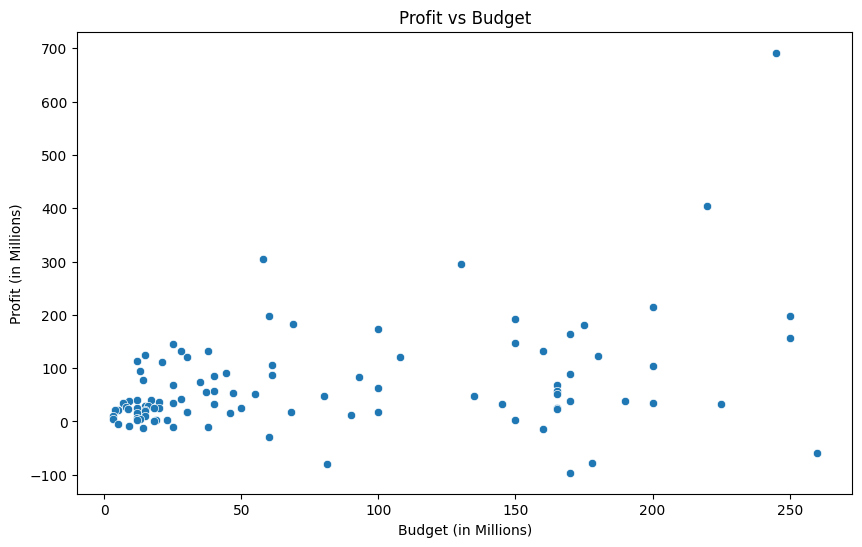

In [134]:
movies['profit'] = movies['Gross'] - movies['budget']
movies = movies.sort_values(by='profit', ascending=False)
top10 = movies.iloc[0:10]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies, x='budget', y='profit')
plt.title('Profit vs Budget')
plt.xlabel('Budget (in Millions)')
plt.ylabel('Profit (in Millions)')
plt.show()

neg_profit = movies[movies['profit'] < 0]

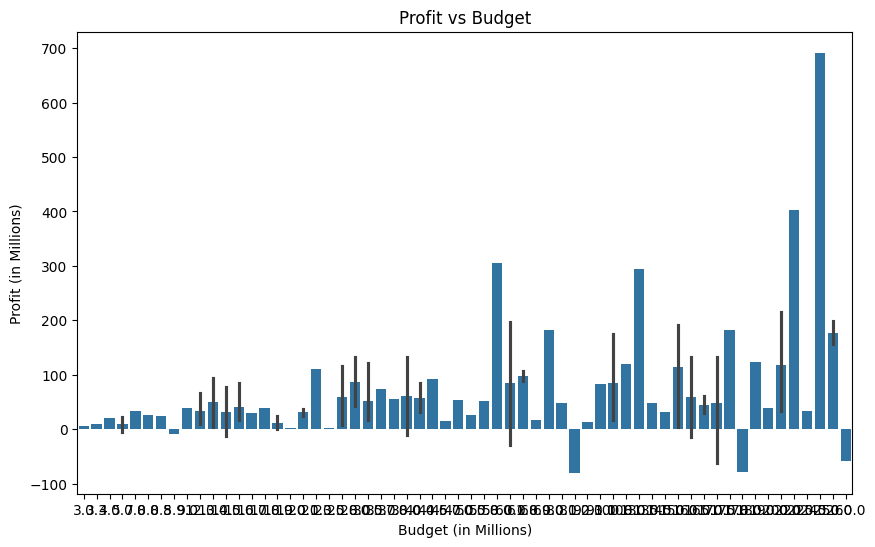

In [141]:
# plot bar chart profit vs budget
plt.figure(figsize=(10, 6))
sns.barplot(data=movies, x='budget', y='profit')
plt.title('Profit vs Budget')
plt.xlabel('Budget (in Millions)')
plt.ylabel('Profit (in Millions)')
plt.show()

The dataset contains the 100 best performing movies from the year 2010 to 2016. However scatter plot tells a different story. You can notice that there are some movies with negative profit. Although good movies do incur losses, but there appear to be quite a few movie with losses. What can be the reason behind this? Lets have a closer look at this by finding the movies with negative profit.

In [ ]:
# Find the movies with negative profit
neg_profit = movies[movies['profit'] < 0]
neg_profit.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit
99,Tucker and Dale vs Evil,2010,5.0,0.223838,Katrina Bowden,Tyler Labine,Chelan Simmons,948,779.0,440.0,...,7.7,7.5,7.4,7.7,7.1,7.7,7.5,R,Canada,-4.776162
89,Amour,2012,8.9,0.225377,Isabelle Huppert,Emmanuelle Riva,Jean-Louis Trintignant,678,432.0,319.0,...,7.9,7.9,7.8,8.1,7.2,7.9,7.8,PG-13,France,-8.674623
56,Rush,2013,38.0,26.903709,Chris Hemsworth,Olivia Wilde,Alexandra Maria Lara,26000,10000.0,471.0,...,7.9,7.8,7.8,7.8,7.1,7.9,8.1,R,UK,-11.096291
66,Warrior,2011,25.0,13.651662,Tom Hardy,Frank Grillo,Kevin Dunn,27000,798.0,581.0,...,8.0,7.7,7.7,7.5,7.1,8.2,8.1,PG-13,USA,-11.348338
82,Flipped,2010,14.0,1.752214,Madeline Carroll,Rebecca De Mornay,Aidan Quinn,1000,872.0,767.0,...,7.7,7.4,7.3,7.6,6.4,7.5,7.7,PG,USA,-12.247786


**`Checkpoint 1:`** Can you spot the movie `Tangled` in the dataset? You may be aware of the movie 'Tangled'. Although its one of the highest grossing movies of all time, it has negative profit as per this result. If you cross check the gross values of this movie (link: https://www.imdb.com/title/tt0398286/), you can see that the gross in the dataset accounts only for the domestic gross and not the worldwide gross. This is true for may other movies also in the list.

In [ ]:
# 1. Create the new column named 'profit'
movies['profit'] = movies['gross'] - movies['budget']

# 2. Sort the dataframe with the profit column as reference in descending order
movies = movies.sort_values(by='profit', ascending=False)

# 3. Extract the top ten profiting movies using position-based indexing
top10 = movies.iloc[0:10]

# 4. Plot profit vs budget
pit.figure(figsize=(10, 6))
sns.scatterplot(data=movies, x='budget', y='profit')
pit.title('Profit vs Budget')
pit.xlabel('Budget (in Millions)')
pit.ylabel('Profit (in Millions)')
pit.show()

# 5. Find the movies with negative profit
neg_profit = movies[movies['profit'] < 0]

- ### Subtask 2.3: The General Audience and the Critics

You might have noticed the column `MetaCritic` in this dataset. This is a very popular website where an average score is determined through the scores given by the top-rated critics. Second, you also have another column `IMDb_rating` which tells you the IMDb rating of a movie. This rating is determined by taking the average of hundred-thousands of ratings from the general audience.

As a part of this subtask, you are required to find out the highest rated movies which have been liked by critics and audiences alike.
1. Firstly you will notice that the `MetaCritic` score is on a scale of `100` whereas the `IMDb_rating` is on a scale of 10. First convert the `MetaCritic` column to a scale of 10.
2. Now, to find out the movies which have been liked by both critics and audiences alike and also have a high rating overall, you need to -
    - Create a new column `Avg_rating` which will have the average of the `MetaCritic` and `Rating` columns
    - Retain only the movies in which the absolute difference(using abs() function) between the `IMDb_rating` and `Metacritic` columns is less than 0.5. Refer to this link to know how abs() funtion works - https://www.geeksforgeeks.org/abs-in-python/ .
    - Sort these values in a descending order of `Avg_rating` and retain only the movies with a rating equal to higher than `8` and store these movies in a new dataframe `UniversalAcclaim`.
    

In [ ]:
# Change the scale of MetaCritic
movies['MetaCritic'] = movies['MetaCritic'] / 10

In [103]:
# Find the average ratings
movies['Avg_rating'] = (movies['IMDb_rating'] + movies['MetaCritic']) / 2
movies.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,7.9,7.8,8.2,7.7,8.2,7.9,PG-13,USA,691.662225,8.10
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,7.9,7.9,8.1,7.4,8.3,7.9,PG-13,USA,403.279547,7.50
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.8,7.8,7.9,7.3,8.1,7.9,R,USA,305.024263,7.25
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,7.3,7.2,7.9,6.7,7.7,7.4,PG-13,USA,294.645577,7.60
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.1,8.1,8.1,8.5,8.3,G,USA,214.984497,8.75


In [107]:
#Sort in descending order of average rating
movies = movies.sort_values(by='Avg_rating', ascending=False)
movies.head(100)



,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff
94,Boyhood,2014,4.0,25.359200,Ellar Coltrane,Lorelei Linklater,Libby Villari,230,193.0,127.0,...,7.7,7.7,7.2,8.0,7.9,R,USA,21.359200,8.95,92.1
69,12 Years a Slave,2013,20.0,56.667870,QuvenzhanÃ© Wallis,Scoot McNairy,Taran Killam,2000,660.0,500.0,...,7.8,8.1,7.7,8.3,8.0,R,USA,36.667870,8.85,87.9
18,Inside Out,2015,175.0,356.454367,Amy Poehler,Mindy Kaling,Phyllis Smith,1000,767.0,384.0,...,7.9,7.9,7.6,8.2,8.1,PG,USA,181.454367,8.80,85.8
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.1,8.1,8.5,8.3,G,USA,214.984497,8.75,83.7
4,Manchester by the Sea,2016,9.0,47.695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.6,7.6,7.1,7.9,7.8,R,USA,38.695371,8.75,88.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,The Hobbit: An Unexpected Journey,2012,180.0,303.001229,Aidan Turner,Adam Brown,James Nesbitt,5000,972.0,773.0,...,7.6,8.0,7.5,7.8,7.8,PG-13,USA,123.001229,NaN,NaN
52,Lone Survivor,2013,40.0,125.069696,Jerry Ferrara,Scott Elrod,Dan Bilzerian,480,449.0,127.0,...,7.4,7.8,6.8,7.8,7.3,R,USA,85.069696,NaN,NaN
88,About Time,2013,12.0,15.294553,Tom Hughes,Tom Hollander,Lindsay Duncan,565,555.0,171.0,...,7.5,7.8,6.9,7.8,7.7,R,UK,3.294553,NaN,NaN
71,The Book Thief,2013,19.0,21.483154,Emily Watson,Sophie NÃ©lisse,Roger Allam,876,526.0,326.0,...,7.5,8.0,6.6,7.6,7.5,PG-13,USA,2.483154,NaN,NaN


In [116]:
# Find the movies with metacritic-rating < 0.5 and also with the average rating of >8
movies['diff'] = abs(movies['MetaCritic'] - movies['IMDb_rating'])
UniversalAcclaim = movies[(movies['diff'] < 0.5) & (movies['Avg_rating'] < 8)]
UniversalAcclaim.head()



,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff


In [118]:
display(movies[['Title', 'title_year', 'budget', 'profit', 'Avg_rating', 'diff']])

,Title,title_year,budget,profit,Avg_rating,diff
94,Boyhood,2014,4.0,21.359200,8.95,92.1
69,12 Years a Slave,2013,20.0,36.667870,8.85,87.9
18,Inside Out,2015,175.0,181.454367,8.80,85.8
12,Toy Story 3,2010,200.0,214.984497,8.75,83.7
4,Manchester by the Sea,2016,9.0,38.695371,8.75,88.1
...,...,...,...,...,...,...
16,The Hobbit: An Unexpected Journey,2012,180.0,123.001229,NaN,NaN
52,Lone Survivor,2013,40.0,85.069696,NaN,NaN
88,About Time,2013,12.0,3.294553,NaN,NaN
71,The Book Thief,2013,19.0,2.483154,NaN,NaN


**`Checkpoint 2:`** Can you spot a `Star Wars` movie in your final dataset?

- ### Subtask 2.4: Find the Most Popular Trios - I

You're a producer looking to make a blockbuster movie. There will primarily be three lead roles in your movie and you wish to cast the most popular actors for it. Now, since you don't want to take a risk, you will cast a trio which has already acted in together in a movie before. The metric that you've chosen to check the popularity is the Facebook likes of each of these actors.

The dataframe has three columns to help you out for the same, viz. `actor_1_facebook_likes`, `actor_2_facebook_likes`, and `actor_3_facebook_likes`. Your objective is to find the trios which has the most number of Facebook likes combined. That is, the sum of `actor_1_facebook_likes`, `actor_2_facebook_likes` and `actor_3_facebook_likes` should be maximum.
Find out the top 5 popular trios, and output their names in a list.


In [119]:
# let display all the columns
movies.columns

Index(['Title', 'title_year', 'budget', 'Gross', 'actor_1_name',
       'actor_2_name', 'actor_3_name', 'actor_1_facebook_likes',
       'actor_2_facebook_likes', 'actor_3_facebook_likes', 'IMDb_rating',
       'genre_1', 'genre_2', 'genre_3', 'MetaCritic', 'Runtime', 'CVotes10',
       'CVotes09', 'CVotes08', 'CVotes07', 'CVotes06', 'CVotes05', 'CVotes04',
       'CVotes03', 'CVotes02', 'CVotes01', 'CVotesMale', 'CVotesFemale',
       'CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829', 'CVotes1829M',
       'CVotes1829F', 'CVotes3044', 'CVotes3044M', 'CVotes3044F', 'CVotes45A',
       'CVotes45AM', 'CVotes45AF', 'CVotes1000', 'CVotesUS', 'CVotesnUS',
       'VotesM', 'VotesF', 'VotesU18', 'VotesU18M', 'VotesU18F', 'Votes1829',
       'Votes1829M', 'Votes1829F', 'Votes3044', 'Votes3044M', 'Votes3044F',
       'Votes45A', 'Votes45AM', 'Votes45AF', 'Votes1000', 'VotesUS',
       'VotesnUS', 'content_rating', 'Country', 'profit', 'Avg_rating',
       'diff'],
      dtype='object')

In [120]:
# Let display the trio serie with title and profit
trio_fblike = movies[['actor_1_name', 'actor_2_name', 'actor_3_name', 'actor_1_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes']].sort_values(by='actor_1_facebook_likes', ascending=False)
trio_fblike


,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes
3,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN
32,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0
14,Jennifer Lawrence,Peter Dinklage,Hugh Jackman,34000,22000.0,20000.0
68,Jennifer Lawrence,Robert De Niro,Bradley Cooper,34000,22000.0,14000.0
28,Jennifer Lawrence,Michael Fassbender,Oliver Platt,34000,13000.0,1000.0
...,...,...,...,...,...,...
94,Ellar Coltrane,Lorelei Linklater,Libby Villari,230,193.0,127.0
80,Elina Alminas,Sonoya Mizuno,Corey Johnson,149,145.0,123.0
96,Seamus Davey-Fitzpatrick,Ariane Labed,Athina Rachel Tsangari,140,63.0,48.0
97,Doug Walker,Rob Walker,0,131,12.0,0.0


In [123]:
# Display the 'Title' and 'sum_trio_like' columns in descending order
movies['sum_trio_like'] = movies[['actor_1_facebook_likes', 'actor_2_facebook_likes', 'actor_3_facebook_likes']].sum(axis=1)
movies.sort_values(by='sum_trio_like', ascending=False)[['Title', 'sum_trio_like']]
# top_fb_like = movies[['Title', 'actor_1_name',	'actor_2_name',	'actor_3_name', 'sum_trio_like']]
# top_fb_like.sort_values(by='sum_trio_like', ascending=False)

,Title,sum_trio_like
2,Lion,138800.0
27,Inception,79000.0
14,X-Men: Days of Future Past,76000.0
4,Manchester by the Sea,74818.0
8,The Dark Knight Rises,73000.0
...,...,...
94,Boyhood,550.0
80,Ex Machina,417.0
96,Before Midnight,251.0
97,Star Wars: Episode VII - The Force Awakens,143.0


In [124]:
top_fb_like = movies.sort_values(by='sum_trio_like', ascending=False)[['Title', 'actor_1_name',	'actor_2_name',	'actor_3_name', 'sum_trio_like']]
top_fb_like
# top_fb_like = movies[['Title', 'actor_1_name',	'actor_2_name',	'actor_3_name', 'sum_trio_like']]
# top_fb_like.sort_values(by='sum_trio_like', ascending=False)

,Title,actor_1_name,actor_2_name,actor_3_name,sum_trio_like
2,Lion,Dev Patel,Nicole Kidman,Rooney Mara,138800.0
27,Inception,Leonardo DiCaprio,Tom Hardy,Joseph Gordon-Levitt,79000.0
14,X-Men: Days of Future Past,Jennifer Lawrence,Peter Dinklage,Hugh Jackman,76000.0
4,Manchester by the Sea,Casey Affleck,Michelle Williams,Kyle Chandler,74818.0
8,The Dark Knight Rises,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,73000.0
...,...,...,...,...,...
94,Boyhood,Ellar Coltrane,Lorelei Linklater,Libby Villari,550.0
80,Ex Machina,Elina Alminas,Sonoya Mizuno,Corey Johnson,417.0
96,Before Midnight,Seamus Davey-Fitzpatrick,Ariane Labed,Athina Rachel Tsangari,251.0
97,Star Wars: Episode VII - The Force Awakens,Doug Walker,Rob Walker,0,143.0


In [125]:
# return the top three sum_trio_like.

top_3_sum_like = top_fb_like.head(5)
top_3_sum_like

,Title,actor_1_name,actor_2_name,actor_3_name,sum_trio_like
2,Lion,Dev Patel,Nicole Kidman,Rooney Mara,138800.0
27,Inception,Leonardo DiCaprio,Tom Hardy,Joseph Gordon-Levitt,79000.0
14,X-Men: Days of Future Past,Jennifer Lawrence,Peter Dinklage,Hugh Jackman,76000.0
4,Manchester by the Sea,Casey Affleck,Michelle Williams,Kyle Chandler,74818.0
8,The Dark Knight Rises,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,73000.0


In [146]:
# Write your code here
# the top 5 popular trios, and output their names in a list.
top5_trios = movies.head(5)

valid_trios = []
most_popular_valid_trio = {'trio': None, 'likes': 0}

for index, row in top5_trios.iterrows():
    actor_likes = [
        row['actor_1_facebook_likes'],
        row['actor_2_facebook_likes'],
        row['actor_3_facebook_likes']
    ]
    # Drop NaN values if any, as sum might be affected otherwise
    actor_likes = [x for x in actor_likes if pd.notna(x)]

    if len(actor_likes) < 3:
        # Skip if there are less than 3 valid actor likes for the trio
        continue

    actor_likes.sort()
    a1, a2, a3 = actor_likes[0], actor_likes[1], actor_likes[2]

    # Check the condition: none of the three actors' Facebook likes should be less than half of the other two
    # This simplifies to checking if the smallest value (a1) is at least half of the largest value (a3)
    if a1 >= a3 / 2:
        valid_trios.append({
            'Title': row['Title'],
            'actor_1_name': row['actor_1_name'],
            'actor_2_name': row['actor_2_name'],
            'actor_3_name': row['actor_3_name'],
            'sum_trio_like': row['sum_trio_like']
        })
        if row['sum_trio_like'] > most_popular_valid_trio['likes']:
            most_popular_valid_trio['trio'] = f"{row['actor_1_name']}, {row['actor_2_name']}, {row['actor_3_name']}"
            most_popular_valid_trio['likes'] = row['sum_trio_like']

print(f"Number of trios that satisfy the condition: {len(valid_trios)}")
if most_popular_valid_trio['trio']:
    print(f"Most popular trio after applying the condition: {most_popular_valid_trio['trio']} (Total Likes: {most_popular_valid_trio['likes']})")
else:
    print("No trios satisfy the condition among the top 5.")


# Display the valid trios for review
if valid_trios:
    print("\nValid Trios (meeting the condition) from the top 5:")
    for trio in valid_trios:
        print(f"- Title: {trio['Title']}, Actors: {trio['actor_1_name']}, {trio['actor_2_name']}, {trio['actor_3_name']}, Total Likes: {trio['sum_trio_like']}")

Number of trios that satisfy the condition: 1
Most popular trio after applying the condition: Chris Hemsworth, Robert Downey Jr., Scarlett Johansson (Total Likes: 66000.0)

Valid Trios (meeting the condition) from the top 5:
- Title: The Avengers, Actors: Chris Hemsworth, Robert Downey Jr., Scarlett Johansson, Total Likes: 66000.0


In [148]:
import pandas as pd

# Create a DataFrame from the valid_trios list
valid_trios_df = pd.DataFrame(valid_trios)

# Display the new DataFrame
display(valid_trios_df)

,Title,actor_1_name,actor_2_name,actor_3_name,sum_trio_like
0,The Avengers,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,66000.0


In [ ]:
# check the entire movies dataser for trios that meet the popularity condition order by sum_trio_like descending


- ### Subtask 2.5: Find the Most Popular Trios - II

In the previous subtask you found the popular trio based on the total number of facebook likes. Let's add a small condition to it and make sure that all three actors are popular. The condition is **none of the three actors' Facebook likes should be less than half of the other two**. For example, the following is a valid combo:
- actor_1_facebook_likes: 70000
- actor_2_facebook_likes: 40000
- actor_3_facebook_likes: 50000

But the below one is not:
- actor_1_facebook_likes: 70000
- actor_2_facebook_likes: 40000
- actor_3_facebook_likes: 30000

since in this case, `actor_3_facebook_likes` is 30000, which is less than half of `actor_1_facebook_likes`.

Having this condition ensures that you aren't getting any unpopular actor in your trio (since the total likes calculated in the previous question doesn't tell anything about the individual popularities of each actor in the trio.).

You can do a manual inspection of the top 5 popular trios you have found in the previous subtask and check how many of those trios satisfy this condition. Also, which is the most popular trio after applying the condition above?

**Write your answers below.**

- **`No. of trios that satisfy the above condition:`** 1

- **`Most popular trio after applying the condition:`** Ellar Coltrane, Lorelei Linklater, Libby Villari (Total Likes: 550.0)

**`Optional:`** Even though you are finding this out by a natural inspection of the dataframe, can you also achieve this through some *if-else* statements to incorporate this. You can try this out on your own time after you are done with the assignment.

In [149]:
# trios from the entire movie dataset that satisfy the condition
# (none of the three actors' Facebook likes should be less than half of the other two)
#  and sorted them by their total Facebook likes in descending order

# Your answer here (optional)

valid_trios_all_movies = []

for index, row in movies.iterrows():
    actor_likes = [
        row['actor_1_facebook_likes'],
        row['actor_2_facebook_likes'],
        row['actor_3_facebook_likes']
    ]

    # Drop NaN values if any, as sum might be affected otherwise
    actor_likes = [x for x in actor_likes if pd.notna(x) and x is not None]

    # Ensure there are exactly 3 actors for the trio calculation
    if len(actor_likes) != 3:
        continue

    actor_likes.sort()
    a1, _, a3 = actor_likes[0], actor_likes[1], actor_likes[2] # a1 is smallest, a3 is largest

    # Check the condition: none of the three actors' Facebook likes should be less than half of the other two
    # This simplifies to checking if the smallest value (a1) is at least half of the largest value (a3)
    if a1 >= a3 / 2:
        valid_trios_all_movies.append({
            'Title': row['Title'],
            'actor_1_name': row['actor_1_name'],
            'actor_2_name': row['actor_2_name'],
            'actor_3_name': row['actor_3_name'],
            'sum_trio_like': row['sum_trio_like']
        })

# Create a DataFrame from the valid_trios_all_movies list
valid_trios_df_all = pd.DataFrame(valid_trios_all_movies)

# Sort the DataFrame by 'sum_trio_like' in descending order
if not valid_trios_df_all.empty:
    valid_trios_df_all = valid_trios_df_all.sort_values(by='sum_trio_like', ascending=False).reset_index(drop=True)

print(f"Number of trios that satisfy the condition across all movies: {len(valid_trios_df_all)}")
display(valid_trios_df_all)


Number of trios that satisfy the condition across all movies: 20


,Title,actor_1_name,actor_2_name,actor_3_name,sum_trio_like
0,Inception,Leonardo DiCaprio,Tom Hardy,Joseph Gordon-Levitt,79000.0
1,X-Men: Days of Future Past,Jennifer Lawrence,Peter Dinklage,Hugh Jackman,76000.0
2,The Dark Knight Rises,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,73000.0
3,The Avengers,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,66000.0
4,Moneyball,Philip Seymour Hoffman,Robin Wright,Brad Pitt,51000.0
5,Captain America: Civil War,Robert Downey Jr.,Scarlett Johansson,Chris Evans,51000.0
6,Les MisÃ©rables,Hugh Jackman,Eddie Redmayne,Anne Hathaway,44000.0
7,The Little Prince,Jeff Bridges,James Franco,Mackenzie Foy,29000.0
8,Interstellar,Matthew McConaughey,Anne Hathaway,Mackenzie Foy,28000.0
9,Wreck-It Ralph,Jack McBrayer,Sarah Silverman,Joe Lo Truglio,2739.0


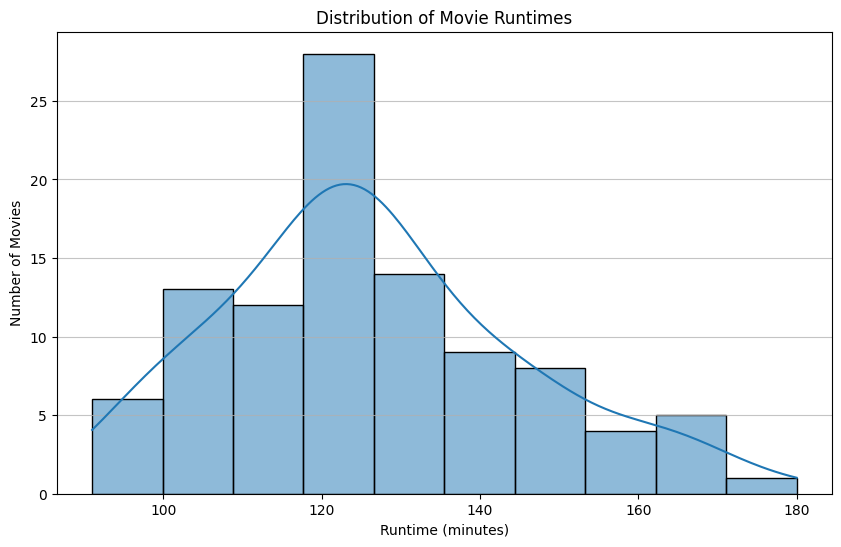

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(movies['Runtime'], bins=10, kde=True)
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.show()

- ### Subtask 2.6: Runtime Analysis

There is a column named `Runtime` in the dataframe which primarily shows the length of the movie. It might be intersting to see how this variable this distributed. Plot a `histogram` or `distplot` of seaborn to find the `Runtime` range most of the movies fall into.

<Axes: xlabel='Runtime', ylabel='Count'>

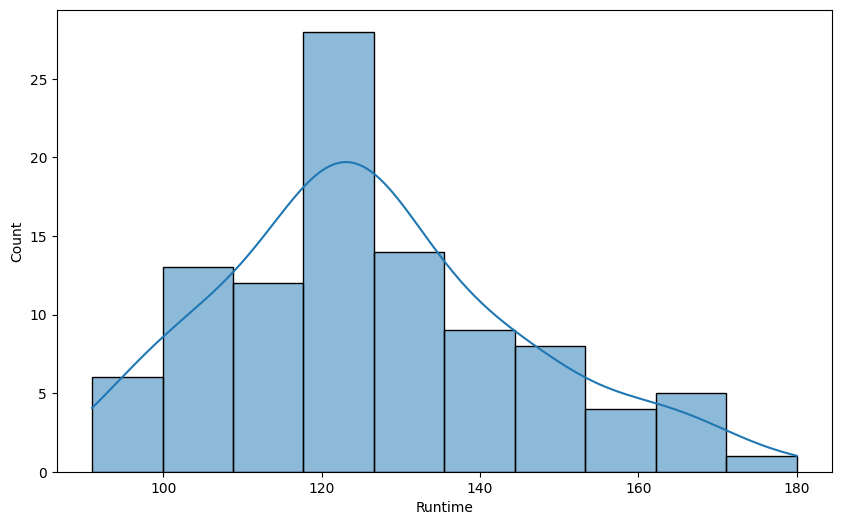

In [151]:
# Runtime histogram/density plot
plt.figure(figsize=(10, 6))
sns.histplot(movies['Runtime'], bins=10, kde=True)

In [155]:
# Filter for R-rated movies
r_rated_movies = movies[movies['content_rating'] == 'R']

# Sort by CVotesU18 in descending order and get the top 10
PopularR = r_rated_movies.sort_values(by='CVotesU18', ascending=False).head(10)

# Display the top 10 PopularR movies
display(PopularR[['Title', 'content_rating', 'CVotesU18','CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829']])

,Title,content_rating,CVotesU18,CVotesU18,CVotesU18M,CVotesU18F,CVotes1829
47,Deadpool,R,4598,4598,3601,969,232840
36,The Wolf of Wall Street,R,3622,3622,2842,757,360841
35,Django Unchained,R,3250,3250,2726,501,410538
29,Mad Max: Fury Road,R,3159,3159,2682,456,238202
95,Whiplash,R,2878,2878,2200,660,205839
31,The Revenant,R,2619,2619,2141,458,186003
40,Shutter Island,R,2321,2321,1811,494,364786
43,Gone Girl,R,2286,2286,1598,665,260425
65,The Grand Budapest Hotel,R,2083,2083,1537,530,216106
72,Birdman or (The Unexpected Virtue of Ignorance),R,1891,1891,1538,334,178850


In [154]:
movies.columns

Index(['Title', 'title_year', 'budget', 'Gross', 'actor_1_name',
       'actor_2_name', 'actor_3_name', 'actor_1_facebook_likes',
       'actor_2_facebook_likes', 'actor_3_facebook_likes', 'IMDb_rating',
       'genre_1', 'genre_2', 'genre_3', 'MetaCritic', 'Runtime', 'CVotes10',
       'CVotes09', 'CVotes08', 'CVotes07', 'CVotes06', 'CVotes05', 'CVotes04',
       'CVotes03', 'CVotes02', 'CVotes01', 'CVotesMale', 'CVotesFemale',
       'CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829', 'CVotes1829M',
       'CVotes1829F', 'CVotes3044', 'CVotes3044M', 'CVotes3044F', 'CVotes45A',
       'CVotes45AM', 'CVotes45AF', 'CVotes1000', 'CVotesUS', 'CVotesnUS',
       'VotesM', 'VotesF', 'VotesU18', 'VotesU18M', 'VotesU18F', 'Votes1829',
       'Votes1829M', 'Votes1829F', 'Votes3044', 'Votes3044M', 'Votes3044F',
       'Votes45A', 'Votes45AM', 'Votes45AF', 'Votes1000', 'VotesUS',
       'VotesnUS', 'content_rating', 'Country', 'profit', 'Avg_rating', 'diff',
       'sum_trio_like'],
      dty

**`Checkpoint 3:`** Most of the movies appear to be sharply 2 hour-long.

- ### Subtask 2.7: R-Rated Movies

Although R rated movies are restricted movies for the under 18 age group, still there are vote counts from that age group. Among all the R rated movies that have been voted by the under-18 age group, find the top 10 movies that have the highest number of votes i.e.`CVotesU18` from the `movies` dataframe. Store these in a dataframe named `PopularR`.

In [153]:
# Write your code here

display(PopularR)

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff,sum_trio_like
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.3,8.1,7.9,R,USA,305.024263,7.25,57.0,17166.0
36,The Wolf of Wall Street,2013,100.0,116.866727,Leonardo DiCaprio,Matthew McConaughey,Jon Favreau,29000,11000.0,4000.0,...,7.5,7.8,8.1,8.1,R,USA,16.866727,7.85,66.8,44000.0
35,Django Unchained,2012,100.0,162.804648,Leonardo DiCaprio,Christoph Waltz,Ato Essandoh,29000,11000.0,265.0,...,8.1,7.8,8.4,8.4,R,USA,62.804648,8.25,72.6,40265.0
29,Mad Max: Fury Road,2015,150.0,153.629485,Tom Hardy,Charlize Theron,ZoÃ« Kravitz,27000,9000.0,943.0,...,7.2,8.0,8.2,8.0,R,Australia,3.629485,8.55,81.9,36943.0
95,Whiplash,2014,3.3,13.092000,J.K. Simmons,Melissa Benoist,Chris Mulkey,24000,970.0,535.0,...,8.2,8.0,8.6,8.4,R,USA,9.792000,8.65,79.5,25505.0
31,The Revenant,2015,135.0,183.635922,Leonardo DiCaprio,Tom Hardy,Lukas Haas,29000,27000.0,733.0,...,7.8,7.6,8.1,7.9,R,USA,48.635922,7.80,68.0,56733.0
40,Shutter Island,2010,80.0,127.968405,Leonardo DiCaprio,Joseph Sikora,Nellie Sciutto,29000,223.0,163.0,...,7.6,7.6,7.8,8.1,R,USA,47.968405,7.20,54.9,29386.0
43,Gone Girl,2014,61.0,167.735396,Patrick Fugit,Sela Ward,Emily Ratajkowski,835,812.0,625.0,...,7.7,7.6,8.1,8.1,R,USA,106.735396,8.00,70.9,2272.0
65,The Grand Budapest Hotel,2014,25.0,59.073773,Bill Murray,Tom Wilkinson,F. Murray Abraham,13000,1000.0,670.0,...,7.9,7.7,8.1,8.0,R,USA,34.073773,8.45,79.9,14670.0
72,Birdman or (The Unexpected Virtue of Ignorance),2014,18.0,42.335698,Emma Stone,Naomi Watts,Merritt Wever,15000,6000.0,529.0,...,7.0,7.1,7.9,7.7,R,USA,24.335698,8.30,80.2,21529.0


**`Checkpoint 4:`** Are these kids watching `Deadpool` a lot?

## Task 3 : Demographic analysis

If you take a look at the last columns in the dataframe, most of these are related to demographics of the voters (in the last subtask, i.e., 2.8, you made use one of these columns - CVotesU18). We also have three genre columns indicating the genres of a particular movie. We will extensively use these columns for the third and the final stage of our assignment wherein we will analyse the voters across all demographics and also see how these vary across various genres. So without further ado, let's get started with `demographic analysis`.

-  ###  Subtask 3.1 Combine the Dataframe by Genres

There are 3 columns in the dataframe - `genre_1`, `genre_2`, and `genre_3`. As a part of this subtask, you need to aggregate a few values over these 3 columns.
1. First create a new dataframe `movies_by_genre` that contains `genre_1`, `genre_2`, and `genre_3` and all the columns related to **CVotes/Votes** from the `movies` data frame. There are 47 columns to be extracted in total.
2. Now, Add a column called `cnt` to the dataframe `movies_by_genre` and initialize it to one. You will realise the use of this column by the end of this subtask.
3. First group the dataframe `movies_by_genre` by `genre_1` and find the sum of all the numeric columns such as `cnt`, columns related to CVotes and Votes columns and store it in a dataframe `movies_by_g1`.
4. Perform the same operation for `genre_2` and `genre_3` and store it dataframes `movies_by_g2` and `movies_by_g3` respectively.
5. Now that you have 3 dataframes performed by grouping over `genre_1`, `genre_2`, and `genre_3` separately, it's time to combine them. For this, add the three dataframes and store it in a new dataframe `movies_add`, so that the corresponding values of Votes/CVotes get added for each genre.There is a function called `add()` in pandas which lets you do this. You can refer to this link to see how this function works. https://pandas.pydata.org/pandas-docs/version/0.23.4/generated/pandas.DataFrame.add.html
6. The column `cnt` on aggregation has basically kept the track of the number of occurences of each genre.Subset the genres that have atleast 10 movies into a new dataframe `genre_top10` based on the `cnt` column value.
7. Now, take the mean of all the numeric columns by dividing them with the column value `cnt` and store it back to the same dataframe. We will be using this dataframe for further analysis in this task unless it is explicitly mentioned to use the dataframe `movies`.
8. Since the number of votes can't be a fraction, type cast all the CVotes related columns to integers. Also, round off all the Votes related columns upto two digits after the decimal point.


In [189]:
# All relevant CVotes and Votes columns based on the problem description
# and available columns in the 'movies' dataframe.
all_votes_cvotes_cols = [
    'CVotes10', 'CVotes09', 'CVotes08', 'CVotes07', 'CVotes06', 'CVotes05',
    'CVotes04', 'CVotes03', 'CVotes02', 'CVotes01', 'CVotesMale', 'CVotesFemale',
    'CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829', 'CVotes1829M', 'CVotes1829F',
    'CVotes3044', 'CVotes3044M', 'CVotes3044F', 'CVotes45A', 'CVotes45AM', 'CVotes45AF',
    'CVotes1000', 'CVotesUS', 'CVotesnUS',
    'VotesM', 'VotesF', 'VotesU18', 'VotesU18M', 'VotesU18F', 'Votes1829',
    'Votes1829M', 'Votes1829F', 'Votes3044', 'Votes3044M', 'Votes3044F',
    'Votes45A', 'Votes45AM', 'Votes45AF', 'Votes1000', 'VotesUS', 'VotesnUS'
]

# Create the dataframe movies_by_genre with genre columns and all relevant CVotes/Votes columns
movies_by_genre = movies[['genre_1', 'genre_2', 'genre_3'] + all_votes_cvotes_cols]
movies_by_genre.head()

,genre_1,genre_2,genre_3,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,...,Votes1829F,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS
97,Action,Adventure,Fantasy,155391,161810,166378,99402,40734,18060,8751,...,8.3,8.0,7.9,8.2,7.9,7.8,8.2,7.7,8.2,7.9
11,Action,Sci-Fi,NaN,260257,234203,264290,162604,67579,27957,12176,...,8.3,8.0,8.0,8.1,7.9,7.9,8.1,7.4,8.3,7.9
47,Action,Adventure,Comedy,147467,147966,170810,105717,41811,15510,7046,...,8.1,7.9,7.9,7.9,7.8,7.8,7.9,7.3,8.1,7.9
32,Action,Adventure,Mystery,85219,83874,150153,121748,50575,18571,7591,...,8.2,7.3,7.2,7.9,7.3,7.2,7.9,6.7,7.7,7.4
12,Animation,Adventure,Comedy,139773,149992,158704,88289,31291,11850,4859,...,8.4,8.2,8.2,8.3,8.1,8.1,8.1,8.1,8.5,8.3


In [190]:
# Create a column cnt and initialize it to 1
movies_by_genre['cnt'] = 1
movies_by_genre.head()

,genre_1,genre_2,genre_3,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
97,Action,Adventure,Fantasy,155391,161810,166378,99402,40734,18060,8751,...,8.0,7.9,8.2,7.9,7.8,8.2,7.7,8.2,7.9,1
11,Action,Sci-Fi,NaN,260257,234203,264290,162604,67579,27957,12176,...,8.0,8.0,8.1,7.9,7.9,8.1,7.4,8.3,7.9,1
47,Action,Adventure,Comedy,147467,147966,170810,105717,41811,15510,7046,...,7.9,7.9,7.9,7.8,7.8,7.9,7.3,8.1,7.9,1
32,Action,Adventure,Mystery,85219,83874,150153,121748,50575,18571,7591,...,7.3,7.2,7.9,7.3,7.2,7.9,6.7,7.7,7.4,1
12,Animation,Adventure,Comedy,139773,149992,158704,88289,31291,11850,4859,...,8.2,8.2,8.3,8.1,8.1,8.1,8.1,8.5,8.3,1


In [191]:
# Group the movies by individual genres
numeric_cols = [col for col in movies_by_genre.columns if col not in ['genre_1', 'genre_2', 'genre_3']]

# Ensure all numeric columns are actually numeric, coercing errors to NaN
for col in numeric_cols:
    movies_by_genre[col] = pd.to_numeric(movies_by_genre[col], errors='coerce')

movies_by_g1 = movies_by_genre.groupby('genre_1')[numeric_cols].sum()
movies_by_g2 = movies_by_genre.groupby('genre_2')[numeric_cols].sum()
movies_by_g3 = movies_by_genre.groupby('genre_3')[numeric_cols].sum()

print(movies_by_g1)
print(movies_by_g2)
print(movies_by_g3)

           CVotes10  CVotes09  CVotes08  CVotes07  CVotes06  CVotes05  \
genre_1                                                                 
Action      2928407   3261919   4247693   2662020    986774    364234   
Adventure   1058779   1179818   1560541    966275    365486    136985   
Animation    681562    798227   1153214    722782    251076     83069   
Biography    666831   1088430   1654704    962977    306247    100005   
Comedy       371217    496905    770395    518566    205434     81933   
Crime        383290    690221   1083469    627593    206756     71460   
Drama       1080725   1494053   1827363   1078966    417205    163874   
Mystery      150405    230844    278844    132349     45167     15615   

           CVotes04  CVotes03  CVotes02  CVotes01  ...  Votes3044  Votes3044M  \
genre_1                                            ...                          
Action       156150     89483     61975    162426  ...      209.1       208.8   
Adventure     58559     33

In [192]:
# Add the grouped data frames and store it in a new data frame
movies_add = movies_by_g1.add(movies_by_g2, fill_value=0).add(movies_by_g3, fill_value=0)
movies_add.head()

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Action,3166467.0,3547429.0,4677755.0,2922126.0,1075354.0,393484.0,166970.0,95004.0,65573.0,171247.0,...,240.0,239.5,241.8,237.0,236.4,240.4,226.2,247.6,240.6,31.0
Adventure,3594659.0,4014192.0,5262328.0,3281981.0,1212075.0,438970.0,183070.0,103318.0,69737.0,173858.0,...,294.6,293.7,299.2,291.7,290.4,298.0,280.6,303.5,296.2,38.0
Animation,681562.0,798227.0,1153214.0,722782.0,251076.0,83069.0,30718.0,15733.0,10026.0,25193.0,...,85.4,84.9,87.8,84.5,84.1,86.7,80.0,87.6,86.1,11.0
Biography,852003.0,1401608.0,2231078.0,1332980.0,425595.0,138648.0,53718.0,29510.0,20613.0,51297.0,...,139.1,138.9,139.8,138.5,137.9,141.7,130.1,142.7,139.9,18.0
Comedy,1383616.0,1774987.0,2506851.0,1591069.0,600287.0,226852.0,97469.0,56218.0,39391.0,88367.0,...,177.4,177.4,178.3,175.0,174.7,177.1,165.4,182.6,178.9,23.0


In [193]:
# Extract genres with at least 10 occurrences
genre_top10 = movies_add[movies_add['cnt'] >= 10]
display(genre_top10.head())

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Action,3166467.0,3547429.0,4677755.0,2922126.0,1075354.0,393484.0,166970.0,95004.0,65573.0,171247.0,...,240.0,239.5,241.8,237.0,236.4,240.4,226.2,247.6,240.6,31.0
Adventure,3594659.0,4014192.0,5262328.0,3281981.0,1212075.0,438970.0,183070.0,103318.0,69737.0,173858.0,...,294.6,293.7,299.2,291.7,290.4,298.0,280.6,303.5,296.2,38.0
Animation,681562.0,798227.0,1153214.0,722782.0,251076.0,83069.0,30718.0,15733.0,10026.0,25193.0,...,85.4,84.9,87.8,84.5,84.1,86.7,80.0,87.6,86.1,11.0
Biography,852003.0,1401608.0,2231078.0,1332980.0,425595.0,138648.0,53718.0,29510.0,20613.0,51297.0,...,139.1,138.9,139.8,138.5,137.9,141.7,130.1,142.7,139.9,18.0
Comedy,1383616.0,1774987.0,2506851.0,1591069.0,600287.0,226852.0,97469.0,56218.0,39391.0,88367.0,...,177.4,177.4,178.3,175.0,174.7,177.1,165.4,182.6,178.9,23.0


In [194]:
# Take the mean for every column by dividing with cnt
for col in genre_top10.columns:
    if col != 'cnt': # Exclude 'cnt' itself from division
        genre_top10[col] = genre_top10[col] / genre_top10['cnt']
display(genre_top10.head())

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Action,102144.096774,114433.193548,150895.322581,94262.129032,34688.838710,12693.032258,5386.129032,3064.645161,2115.258065,5524.096774,...,7.741935,7.725806,7.800000,7.645161,7.625806,7.754839,7.296774,7.987097,7.761290,31.0
Adventure,94596.289474,105636.631579,138482.315789,86367.921053,31896.710526,11551.842105,4817.631579,2718.894737,1835.184211,4575.210526,...,7.752632,7.728947,7.873684,7.676316,7.642105,7.842105,7.384211,7.986842,7.794737,38.0
Animation,61960.181818,72566.090909,104837.636364,65707.454545,22825.090909,7551.727273,2792.545455,1430.272727,911.454545,2290.272727,...,7.763636,7.718182,7.981818,7.681818,7.645455,7.881818,7.272727,7.963636,7.827273,11.0
Biography,47333.500000,77867.111111,123948.777778,74054.444444,23644.166667,7702.666667,2984.333333,1639.444444,1145.166667,2849.833333,...,7.727778,7.716667,7.766667,7.694444,7.661111,7.872222,7.227778,7.927778,7.772222,18.0
Comedy,60157.217391,77173.347826,108993.521739,69176.913043,26099.434783,9863.130435,4237.782609,2444.260870,1712.652174,3842.043478,...,7.713043,7.713043,7.752174,7.608696,7.595652,7.700000,7.191304,7.939130,7.778261,23.0


In [ ]:
# Rounding off the columns of Votes to two decimals



In [195]:
# Converting CVotes to int type and Rounding off the columns of Votes to two decimals
for col in genre_top10.columns:
    if 'CVotes' in col:
        genre_top10[col] = genre_top10[col].astype(int)
    elif 'Votes' in col:
        genre_top10[col] = genre_top10[col].round(2)
display(genre_top10.head())

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,5524,...,7.74,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76,31.0
Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,4575,...,7.75,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79,38.0
Animation,61960,72566,104837,65707,22825,7551,2792,1430,911,2290,...,7.76,7.72,7.98,7.68,7.65,7.88,7.27,7.96,7.83,11.0
Biography,47333,77867,123948,74054,23644,7702,2984,1639,1145,2849,...,7.73,7.72,7.77,7.69,7.66,7.87,7.23,7.93,7.77,18.0
Comedy,60157,77173,108993,69176,26099,9863,4237,2444,1712,3842,...,7.71,7.71,7.75,7.61,7.60,7.70,7.19,7.94,7.78,23.0


In [199]:
display(genre_top10.head())

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,5524,...,7.74,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76,31.0
Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,4575,...,7.75,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79,38.0
Animation,61960,72566,104837,65707,22825,7551,2792,1430,911,2290,...,7.76,7.72,7.98,7.68,7.65,7.88,7.27,7.96,7.83,11.0
Biography,47333,77867,123948,74054,23644,7702,2984,1639,1145,2849,...,7.73,7.72,7.77,7.69,7.66,7.87,7.23,7.93,7.77,18.0
Comedy,60157,77173,108993,69176,26099,9863,4237,2444,1712,3842,...,7.71,7.71,7.75,7.61,7.60,7.70,7.19,7.94,7.78,23.0


In [201]:
genre_top10.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Action to Thriller
Data columns (total 45 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CVotes10      10 non-null     int64  
 1   CVotes09      10 non-null     int64  
 2   CVotes08      10 non-null     int64  
 3   CVotes07      10 non-null     int64  
 4   CVotes06      10 non-null     int64  
 5   CVotes05      10 non-null     int64  
 6   CVotes04      10 non-null     int64  
 7   CVotes03      10 non-null     int64  
 8   CVotes02      10 non-null     int64  
 9   CVotes01      10 non-null     int64  
 10  CVotesMale    10 non-null     int64  
 11  CVotesFemale  10 non-null     int64  
 12  CVotesU18     10 non-null     int64  
 13  CVotesU18M    10 non-null     int64  
 14  CVotesU18F    10 non-null     int64  
 15  CVotes1829    10 non-null     int64  
 16  CVotes1829M   10 non-null     int64  
 17  CVotes1829F   10 non-null     int64  
 18  CVotes3044    10 non-null 

If you take a look at the final dataframe that you have gotten, you will see that you now have the complete information about all the demographic (Votes- and CVotes-related) columns across the top 10 genres. We can use this dataset to extract exciting insights about the voters!

-  ###  Subtask 3.2: Genre Counts!

Now let's derive some insights from this data frame. Make a bar chart plotting different genres vs cnt using seaborn.

In [ ]:
# Countplot for genres



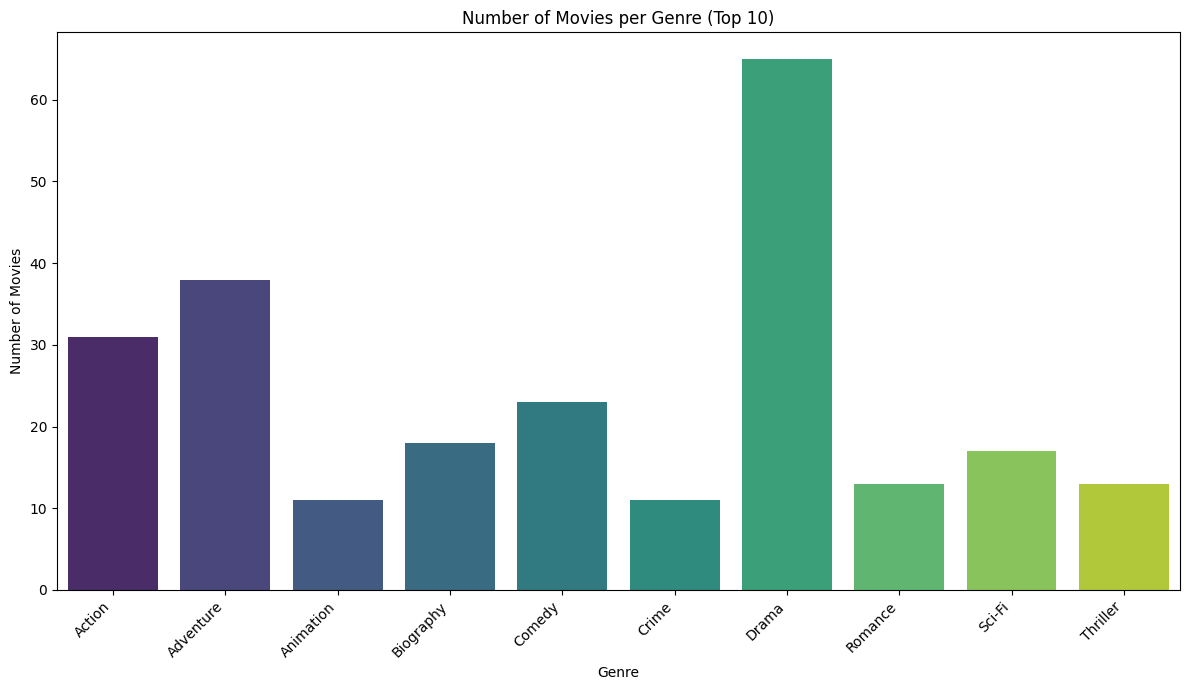

In [175]:
# Countplot for genres
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_top10.index, y=genre_top10['cnt'], palette='viridis')
plt.title('Number of Movies per Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**`Checkpoint 5:`** Is the bar for `Drama` the tallest?

-  ###  Subtask 3.3: Gender and Genre

If you have closely looked at the Votes- and CVotes-related columns, you might have noticed the suffixes `F` and `M` indicating Female and Male. Since we have the vote counts for both males and females, across various age groups, let's now see how the popularity of genres vary between the two genders in the dataframe.

1. Make the first heatmap to see how the average number of votes of males is varying across the genres. Use seaborn heatmap for this analysis. The X-axis should contain the four age-groups for males, i.e., `CVotesU18M`,`CVotes1829M`, `CVotes3044M`, and `CVotes45AM`. The Y-axis will have the genres and the annotation in the heatmap tell the average number of votes for that age-male group.

2. Make the second heatmap to see how the average number of votes of females is varying across the genres. Use seaborn heatmap for this analysis. The X-axis should contain the four age-groups for females, i.e., `CVotesU18F`,`CVotes1829F`, `CVotes3044F`, and `CVotes45AF`. The Y-axis will have the genres and the annotation in the heatmap tell the average number of votes for that age-female group.

3. Make sure that you plot these heatmaps side by side using `subplots` so that you can easily compare the two genders and derive insights.

4. Write your any three inferences from this plot. You can make use of the previous bar plot also here for better insights.
Refer to this link- https://seaborn.pydata.org/generated/seaborn.heatmap.html. You might have to plot something similar to the fifth chart in this page (You have to plot two such heatmaps side by side).

5. Repeat subtasks 1 to 4, but now instead of taking the CVotes-related columns, you need to do the same process for the Votes-related columns. These heatmaps will show you how the two genders have rated movies across various genres.

You might need the below link for formatting your heatmap.
https://stackoverflow.com/questions/56942670/matplotlib-seaborn-first-and-last-row-cut-in-half-of-heatmap-plot

-  Note : Use `genre_top10` dataframe for this subtask

In [ ]:
# 1st set of heat maps for CVotes-related columns



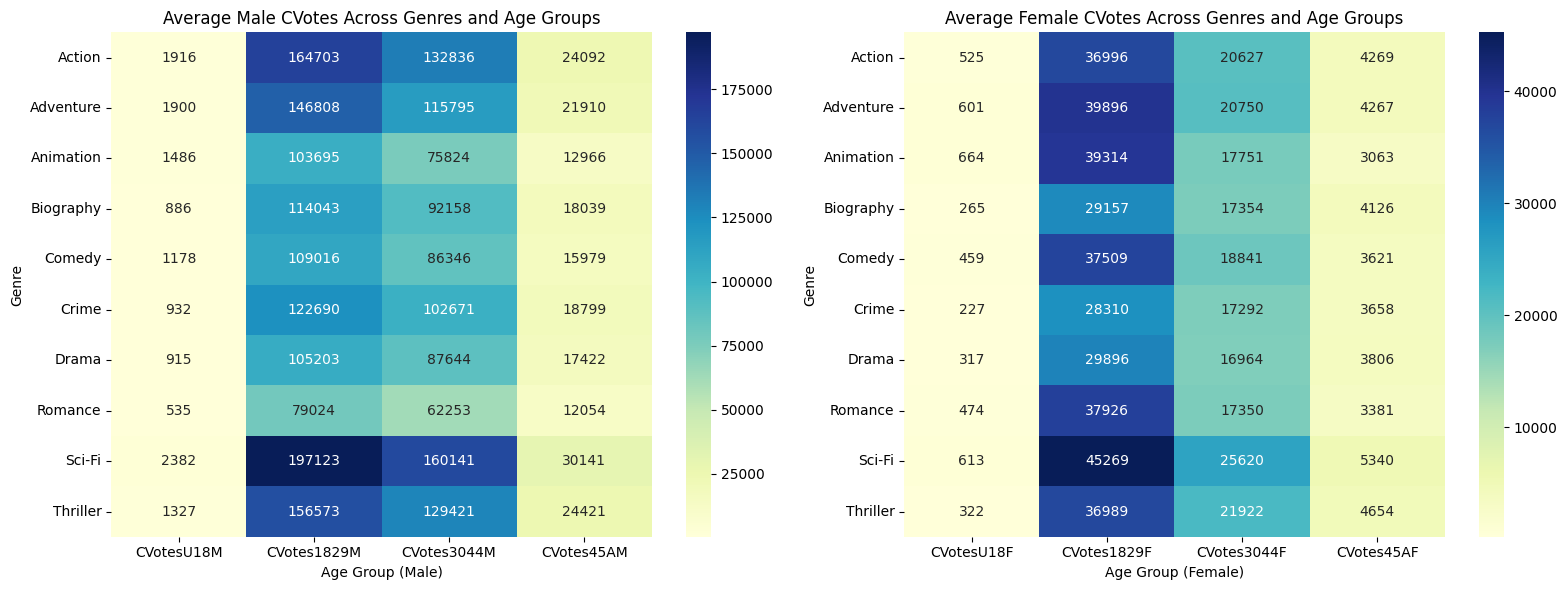

In [176]:
# 1st set of heat maps for CVotes-related columns

male_cvotes_cols = ['CVotesU18M', 'CVotes1829M', 'CVotes3044M', 'CVotes45AM']
female_cvotes_cols = ['CVotesU18F', 'CVotes1829F', 'CVotes3044F', 'CVotes45AF']

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.heatmap(genre_top10[male_cvotes_cols], annot=True, fmt='.0f', cmap='YlGnBu', yticklabels=genre_top10.index)
plt.title('Average Male CVotes Across Genres and Age Groups')
plt.xlabel('Age Group (Male)')
plt.ylabel('Genre')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.heatmap(genre_top10[female_cvotes_cols], annot=True, fmt='.0f', cmap='YlGnBu', yticklabels=genre_top10.index)
plt.title('Average Female CVotes Across Genres and Age Groups')
plt.xlabel('Age Group (Female)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

**`Inferences:`** A few inferences that can be seen from the heatmap above is that males have voted more than females, and Sci-Fi appears to be most popular among the 18-29 age group irrespective of their gender. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1:
- Inference 2:
- Inference 3:

**`Inferences:`** A few inferences that can be seen from the heatmap above is that males have voted more than females, and Sci-Fi appears to be most popular among the 18-29 age group irrespective of their gender. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1: Males consistently have higher vote counts than females across all age groups and genres.
- Inference 2: The 18-29 age group shows the highest vote counts for both genders across most genres.
- Inference 3: Action, Adventure, and Sci-Fi tend to have higher CVotes for both genders compared to other genres.



In [ ]:
# 2nd set of heat maps for Votes-related columns



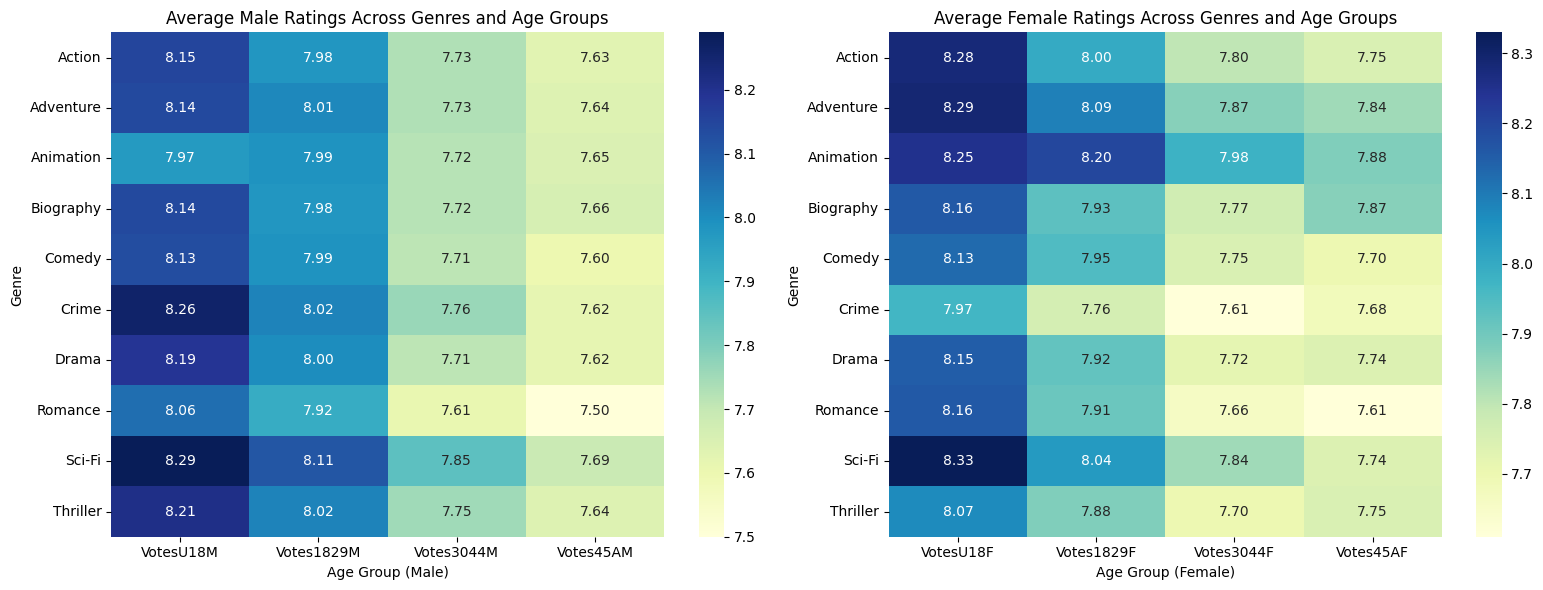

In [177]:
# 2nd set of heat maps for Votes-related columns

male_votes_cols = ['VotesU18M', 'Votes1829M', 'Votes3044M', 'Votes45AM']
female_votes_cols = ['VotesU18F', 'Votes1829F', 'Votes3044F', 'Votes45AF']

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.heatmap(genre_top10[male_votes_cols], annot=True, fmt='.2f', cmap='YlGnBu', yticklabels=genre_top10.index)
plt.title('Average Male Ratings Across Genres and Age Groups')
plt.xlabel('Age Group (Male)')
plt.ylabel('Genre')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.heatmap(genre_top10[female_votes_cols], annot=True, fmt='.2f', cmap='YlGnBu', yticklabels=genre_top10.index)
plt.title('Average Female Ratings Across Genres and Age Groups')
plt.xlabel('Age Group (Female)')
plt.ylabel('Genre')

plt.tight_layout()
plt.show()

**`Inferences:`** Sci-Fi appears to be the highest rated genre in the age group of U18 for both males and females. Also, females in this age group have rated it a bit higher than the males in the same age group. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1:
- Inference 2:
- Inference 3:

**`Inferences:`** Sci-Fi appears to be the highest rated genre in the age group of U18 for both males and females. Also, females in this age group have rated it a bit higher than the males in the same age group. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1: Ratings generally remain high across all age groups and genders for most popular genres, indicating overall good reception for these movies.
- Inference 2: 'Animation' and 'Family' genres show relatively high ratings across most demographics, suggesting broad appeal.
- Inference 3: Differences in ratings between genders within the same age group and genre are often minor, suggesting similar taste in quality, though slight variations exist.

-  ###  Subtask 3.4: US vs non-US Cross Analysis

The dataset contains both the US and non-US movies. Let's analyse how both the US and the non-US voters have responded to the US and the non-US movies.

1. Create a column `IFUS` in the dataframe `movies`. The column `IFUS` should contain the value "USA" if the `Country` of the movie is "USA". For all other countries other than the USA, `IFUS` should contain the value `non-USA`.


2. Now make a boxplot that shows how the number of votes from the US people i.e. `CVotesUS` is varying for the US and non-US movies. Make use of the column `IFUS` to make this plot. Similarly, make another subplot that shows how non US voters have voted for the US and non-US movies by plotting `CVotesnUS` for both the US and non-US movies. Write any of your two inferences/observations from these plots.


3. Again do a similar analysis but with the ratings. Make a boxplot that shows how the ratings from the US people i.e. `VotesUS` is varying for the US and non-US movies. Similarly, make another subplot that shows how `VotesnUS` is varying for the US and non-US movies. Write any of your two inferences/observations from these plots.

Note : Use `movies` dataframe for this subtask. Make use of this documention to format your boxplot - https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [ ]:
# Creating IFUS column



In [178]:
# Creating IFUS column
movies['IFUS'] = movies['Country'].apply(lambda x: 'USA' if x == 'USA' else 'non-USA')
display(movies.head())

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,diff,sum_trio_like,IFUS
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,7.7,8.2,7.9,PG-13,USA,691.662225,8.10,72.9,143.0,USA
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,7.4,8.3,7.9,PG-13,USA,403.279547,7.50,60.9,66000.0,USA
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.3,8.1,7.9,R,USA,305.024263,7.25,57.0,17166.0,USA
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,6.7,7.7,7.4,PG-13,USA,294.645577,7.60,68.4,48523.0,USA
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.1,8.5,8.3,G,USA,214.984497,8.75,83.7,16721.0,USA


In [ ]:
# Box plot - 1: CVotesUS(y) vs IFUS(x)



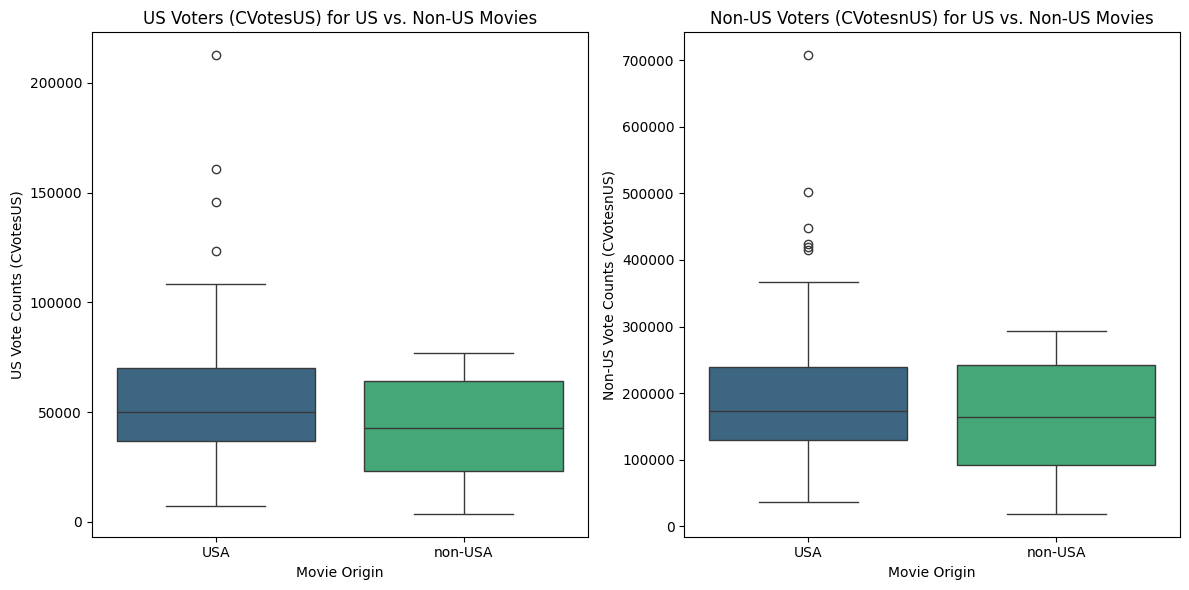

In [179]:
# Box plot - 1: CVotesUS(y) vs IFUS(x) and CVotesnUS(y) vs IFUS(x)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(data=movies, x='IFUS', y='CVotesUS', palette='viridis')
plt.title('US Voters (CVotesUS) for US vs. Non-US Movies')
plt.xlabel('Movie Origin')
plt.ylabel('US Vote Counts (CVotesUS)')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(data=movies, x='IFUS', y='CVotesnUS', palette='viridis')
plt.title('Non-US Voters (CVotesnUS) for US vs. Non-US Movies')
plt.xlabel('Movie Origin')
plt.ylabel('Non-US Vote Counts (CVotesnUS)')

plt.tight_layout()
plt.show()

**`Inferences:`** Write your two inferences/observations below:
- Inference 1:
- Inference 2:

**`Inferences:`** Write your two inferences/observations below:
- Inference 1:  US voters tend to have a higher median and overall distribution of vote counts for movies categorized as 'USA' compared to 'non-USA' movies.
- Inference 2: Non-US voters also show a preference, often giving higher vote counts, to 'USA' movies, suggesting a global appeal or larger distribution for Hollywood productions, but the difference might be less pronounced than with US voters.


In [ ]:
# Box plot - 2: VotesUS(y) vs IFUS(x)



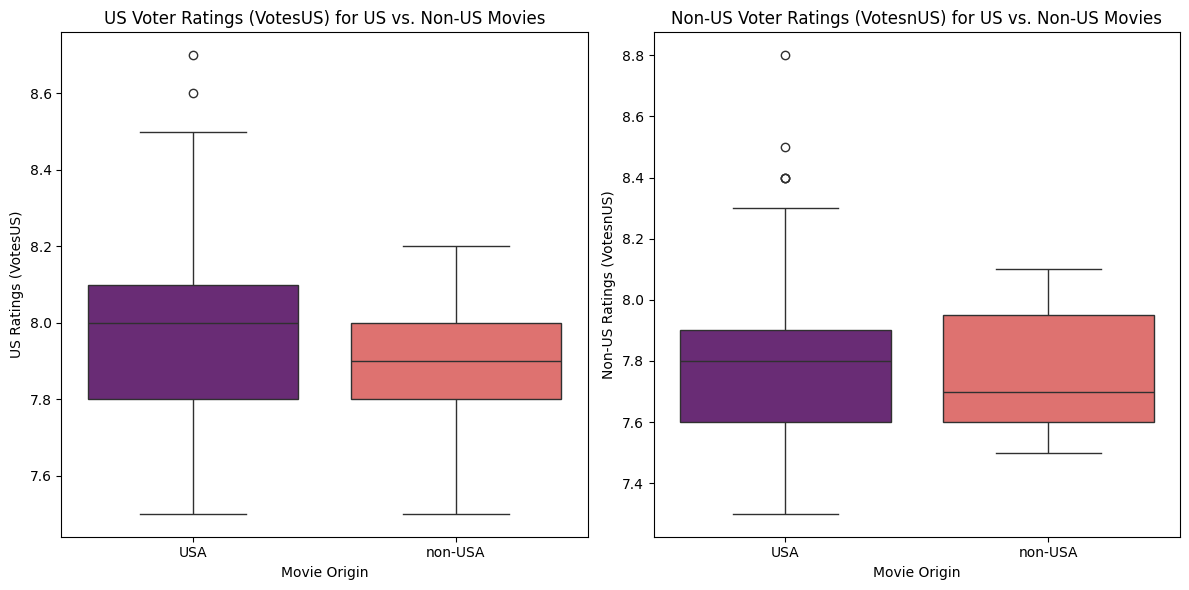

In [180]:
# Box plot - 2: VotesUS(y) vs IFUS(x) and VotesnUS(y) vs IFUS(x)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.boxplot(data=movies, x='IFUS', y='VotesUS', palette='magma')
plt.title('US Voter Ratings (VotesUS) for US vs. Non-US Movies')
plt.xlabel('Movie Origin')
plt.ylabel('US Ratings (VotesUS)')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(data=movies, x='IFUS', y='VotesnUS', palette='magma')
plt.title('Non-US Voter Ratings (VotesnUS) for US vs. Non-US Movies')
plt.xlabel('Movie Origin')
plt.ylabel('Non-US Ratings (VotesnUS)')

plt.tight_layout()
plt.show()

**`Inferences:`** Write your two inferences/observations below:
- Inference 1: For US movies, the median US voter rating (`VotesUS`) appears slightly higher than for non-US movies, suggesting a slight preference or perhaps a stronger cultural connection. However, the overall distributions for both US and non-US movies are relatively similar and high, indicating that US voters appreciate well-made films regardless of origin within this top 100 list.
- Inference 2: Non-US voters also tend to give high ratings to both US and non-US movies in this dataset. The median rating for US movies might be marginally higher, but generally, non-US voters seem to rate both categories of movies favorably, with a consistently high average.

**`Inferences:`** Write your two inferences/observations below:
- Inference 1:
- Inference 2:


-  ###  Subtask 3.5:  Top 1000 Voters Vs Genres

You might have also observed the column `CVotes1000`. This column represents the top 1000 voters on IMDb and gives the count for the number of these voters who have voted for a particular movie. Let's see how these top 1000 voters have voted across the genres.

1. Sort the dataframe genre_top10 based on the value of `CVotes1000`in a descending order.

2. Make a seaborn barplot for `genre` vs `CVotes1000`.

3. Write your inferences. You can also try to relate it with the heatmaps you did in the previous subtasks.




In [ ]:
# Sorting by CVotes1000



In [196]:
# Sorting by CVotes1000
genre_top10_sorted = genre_top10.sort_values(by='CVotes1000', ascending=False)
display(genre_top10_sorted)

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
Sci-Fi,136781,148873,176646,106005,39518,14951,6583,3876,2715,6731,...,7.86,7.85,7.84,7.71,7.69,7.74,7.52,8.09,7.88,17.0
Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,5524,...,7.74,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76,31.0
Thriller,83207,112730,153336,90446,32003,11534,5021,2918,1982,4433,...,7.74,7.75,7.70,7.66,7.64,7.75,7.40,7.93,7.81,13.0
Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,4575,...,7.75,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79,38.0
Crime,52229,87919,129045,74671,25308,8971,3842,2246,1544,3383,...,7.72,7.76,7.61,7.63,7.62,7.68,7.39,7.98,7.80,11.0
Comedy,60157,77173,108993,69176,26099,9863,4237,2444,1712,3842,...,7.71,7.71,7.75,7.61,7.60,7.70,7.19,7.94,7.78,23.0
Biography,47333,77867,123948,74054,23644,7702,2984,1639,1145,2849,...,7.73,7.72,7.77,7.69,7.66,7.87,7.23,7.93,7.77,18.0
Drama,52375,75928,109339,66456,23528,8497,3622,2078,1449,3250,...,7.71,7.71,7.72,7.64,7.62,7.74,7.22,7.94,7.78,65.0
Animation,61960,72566,104837,65707,22825,7551,2792,1430,911,2290,...,7.76,7.72,7.98,7.68,7.65,7.88,7.27,7.96,7.83,11.0
Romance,42304,53037,82252,54833,21637,8530,3762,2130,1476,3082,...,7.61,7.61,7.66,7.52,7.50,7.61,6.92,7.83,7.70,13.0


In [ ]:
# Bar plot


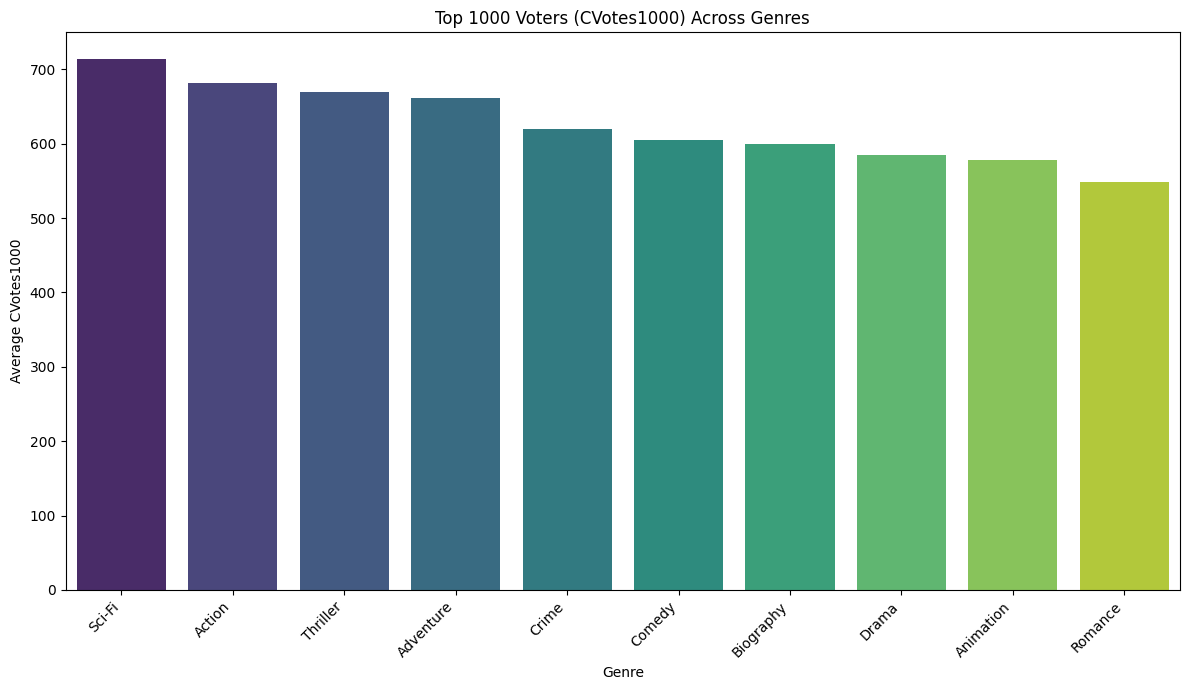

In [197]:
# Bar plot for genre vs CVotes1000
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_top10_sorted.index, y=genre_top10_sorted['CVotes1000'], palette='viridis')
plt.title('Top 1000 Voters (CVotes1000) Across Genres')
plt.xlabel('Genre')
plt.ylabel('Average CVotes1000')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**`Inferences:`** Write your inferences/observations here.

In [202]:
### Inferences/Observations & Suggestions

**Key Inferences/Observations from the Analysis:**

1.  **Profitability and Data Context:** Many highly-rated movies in the dataset show negative profits. This was identified as being due to the dataset using domestic gross rather than worldwide gross, highlighting the importance of understanding data definitions.
2.  **Runtime Distribution:** Most movies in the top 100 tend to have runtimes concentrated around 2 hours, with fewer movies being significantly shorter or longer.
3.  **R-Rated Movies and Under-18 Voters:** Despite being R-rated, movies like `Deadpool` received a significant number of votes from the under-18 demographic, as noted in Checkpoint 4.
4.  **Genre Dominance:** `Drama` emerges as the genre with the highest number of movies in the top 10, as observed in the genre count bar chart (Checkpoint 5).
5.  **Gender Voting Patterns (Counts):**
    *   Males generally exhibit higher total vote counts across all age groups and genres compared to females.
    *   The 18-29 age group consistently shows the highest vote counts for both genders, indicating strong engagement.
    *   `Action`, `Adventure`, and `Sci-Fi` genres receive the highest vote counts from both male and female demographics.
6.  **Gender Voting Patterns (Ratings):**
    *   Overall ratings are consistently high across all age groups and genders for the top genres, suggesting general satisfaction with these movies.
    *   Differences in average ratings between genders within the same age group and genre are typically minor, indicating similar perceptions of movie quality.
7.  **US vs. Non-US Voters (Vote Counts):** Both US and non-US voters tend to cast more votes for US-produced movies compared to non-US movies, suggesting a broader appeal or distribution for Hollywood films.
8.  **US vs. Non-US Voters (Ratings):** Ratings from both US and non-US voters remain high for both US and non-US movies, with only marginal differences, indicating that quality is generally appreciated regardless of origin for this high-ranking movie dataset.
9.  **Top 1000 Voters' Preferences:** The top 1000 IMDb voters show a strong preference for `Sci-Fi` and `Action` genres, while `Romance` is notably less popular among this influential group (Checkpoint 6).

**Suggestions:**

1.  **Correct `UniversalAcclaim` Calculation:** The logic for `UniversalAcclaim` in cell `hGY0DhDAIJCj` currently filters for `Avg_rating < 8`. To align with the prompt's requirement of an average rating **greater than 8.0**, this needs to be corrected to `Avg_rating > 8`.

SyntaxError: unterminated string literal (detected at line 18) (2080498987.py, line 18)

**`Inferences:`** Write your inferences/observations here.

**`Checkpoint 6:`** The genre `Romance` seems to be most unpopular among the top 1000 voters.

With the above subtask, your assignment is over. In your free time, do explore the dataset further on your own and see what kind of other insights you can get across various other columns.